# Temporal Drop Analysis on Skeleton Data

This notebook produces four academic-style visualizations:

1. **Figure 1 — Problem Observation (Temporal Instability):** Variation in hand keypoint positions across consecutive frames, including missing keypoints, illustrating that the temporal sequence is not always stable.

2. **Figure 2 — Temporal Drop (Before vs. After):** Comparison of the skeleton sequence before and after applying temporal drop. Some frames are randomly removed, yet the main motion pattern remains recognizable.

3. **Figure 3 — Sequence Length Distribution:** Histograms and a boxplot comparing sequence lengths before and after temporal drop across the full dataset.

4. **Figure 4 — Mean Sequence Length per Signer:** Bar chart showing the mean number of frames per signer in the original data.


In [3]:
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
import random
import sys, os

# ── Paper-style global rcParams ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : 'white',
    'axes.edgecolor'     : '#333333',
    'axes.linewidth'     : 0.8,
    'axes.grid'          : False,
    'font.family'        : 'serif',
    'font.serif'         : ['Times New Roman', 'DejaVu Serif'],
    'font.size'          : 10,
    'axes.titlesize'     : 10,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 9,
    'xtick.labelsize'    : 8,
    'ytick.labelsize'    : 8,
    'legend.fontsize'    : 9,
    'figure.titlesize'   : 11,
    'figure.titleweight' : 'bold',
    'savefig.dpi'        : 300,
    'savefig.bbox'       : 'tight',
})

# ── Paper-style color palette ─────────────────────────────────────────────────
C_LH      = '#2166AC'   # Left hand  – deep blue
C_RH      = '#D6604D'   # Right hand – muted red
C_EDGE    = '#555555'   # Skeleton edges
C_HIST1   = '#4393C3'   # Histogram original
C_HIST2   = '#F4A582'   # Histogram after drop
C_BOX1    = '#D1E5F0'   # Boxplot fill original
C_BOX2    = '#FDDBC7'   # Boxplot fill after drop
C_MED     = '#B2182B'   # Median line
C_BAR     = '#4393C3'   # Bar chart

pickle_file = '../data/pickle/pose_bisindo.pkl'
with open(pickle_file, 'rb') as f:
    data = pickle.load(f)

print(f"Total videos in dataset: {len(data)}")
print("Sample Video IDs:", list(data.keys())[:10])


Total videos in dataset: 750
Sample Video IDs: ['P01_S001_R01', 'P01_S001_R02', 'P01_S001_R03', 'P01_S001_R04', 'P01_S001_R05', 'P02_S001_R01', 'P02_S001_R02', 'P02_S001_R03', 'P02_S001_R04', 'P02_S001_R05']


In [4]:
# ============================================================
#   PARAMETER SETTINGS
# ============================================================
SELECTED_VIDEO_ID   = 'P01_S001_R01'   # Target video for analysis
SELECTED_START_FRAME = 35              # Starting frame for instability visualization
N_FRAMES_INSTABILITY = 5              # How many consecutive frames to show for instability plot
TEMPORAL_DROP_MAX_DP = 0.15            # Max dropout proportion for temporal drop demo
RANDOM_SEED          = 42             # Reproducibility
# ============================================================

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

if SELECTED_VIDEO_ID not in data:
    raise ValueError(f"Video '{SELECTED_VIDEO_ID}' not found!")

kp = data[SELECTED_VIDEO_ID]['keypoints']  # shape: (T, K, 2)
T, K, _ = kp.shape

# MediaPipe Holistic 86 points layout:
# [0:21]   = Left Hand  (21 points)
# [21:42]  = Right Hand (21 points)
# [42:75]  = Pose       (33 points)
# [75:86]  = Face       (11 points)
HAND_SLICE = slice(0, 42)   # Both hands

print(f"Video           : {SELECTED_VIDEO_ID}")
print(f"Total frames    : {T}")
print(f"Total keypoints : {K} per frame")
print(f"Using frames    : {SELECTED_START_FRAME} – {SELECTED_START_FRAME + N_FRAMES_INSTABILITY - 1}")

Video           : P01_S001_R01
Total frames    : 185
Total keypoints : 86 per frame
Using frames    : 35 – 39


## Figure 1 — Problem Observation: Temporal Instability

3D visualization of hand keypoint sequences across consecutive frames.
The keypoints with the **largest inter-frame displacement** are highlighted, revealing temporal instability in the raw skeleton data.


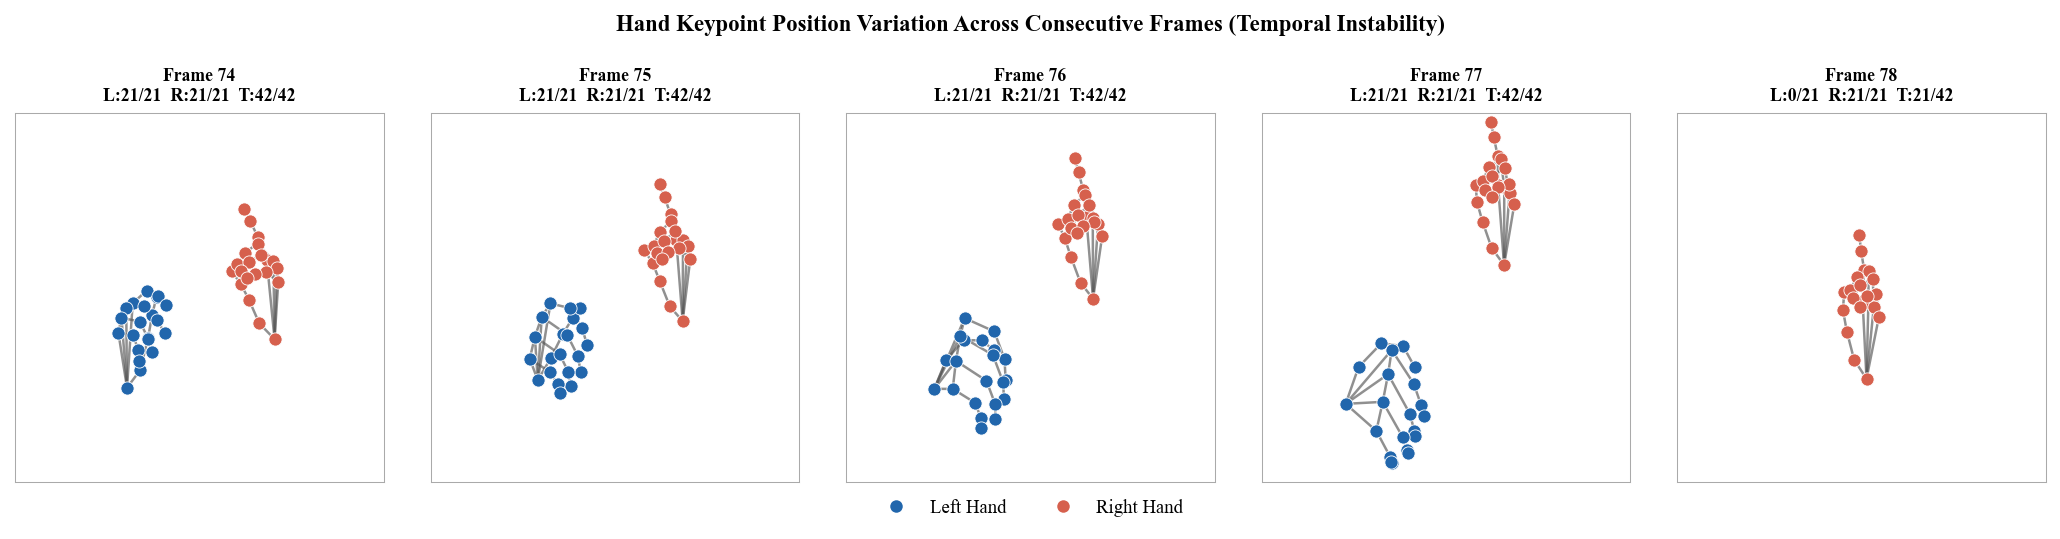

In [5]:
# Figure 1 — Temporal Instability: Hand Keypoint Variation Across Consecutive Frames

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Config ────────────────────────────────────────────────────────────────────
speaker_id  = "P01"
sequence_id = "S023"
start_frame = 74
num_frames  = 5
margin_ratio = 0.08

# ── Index ─────────────────────────────────────────────────────────────────────
IDX_LH   = np.arange(0, 21)
IDX_RH   = np.arange(21, 42)
IDX_HAND = np.arange(0, 42)

# ── Hand skeleton edges ───────────────────────────────────────────────────────
hand_edges = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17)
]
connections = [(u, v) for u, v in hand_edges] + [(u+21, v+21) for u, v in hand_edges]

# ── Load data ─────────────────────────────────────────────────────────────────
match  = [k for k in data.keys() if k.startswith(f"{speaker_id}_{sequence_id}")]
vid    = sorted(match)[0]
kp_vid = data[vid]['keypoints']

frames = []
for i in range(num_frames):
    fidx = start_frame + i
    if fidx >= kp_vid.shape[0]:
        continue
    frame      = kp_vid[fidx].copy()
    valid_mask = (frame[:,0] != 0) | (frame[:,1] != 0)
    frames.append((fidx, frame, valid_mask))

# ── Global alignment ──────────────────────────────────────────────────────────
aligned_frames = []
for fidx, frame, valid_mask in frames:
    idx = IDX_HAND[valid_mask[IDX_HAND]]
    if len(idx) == 0:
        continue
    cx, cy = frame[idx,0].mean(), frame[idx,1].mean()
    frame[:,0] = -(frame[:,0] - cx)
    frame[:,1] -= cy
    aligned_frames.append((fidx, frame, valid_mask))

# ── Global scale ──────────────────────────────────────────────────────────────
all_x, all_y = [], []
for _, frame, valid_mask in aligned_frames:
    idx = IDX_HAND[valid_mask[IDX_HAND]]
    all_x.extend(frame[idx,0]);  all_y.extend(-frame[idx,1])
side = max(max(all_x)-min(all_x), max(all_y)-min(all_y)) * (1 + margin_ratio)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(aligned_frames), figsize=(14, 3.2), dpi=150)
if len(aligned_frames) == 1:
    axes = [axes]

for ax, (fidx, frame, valid_mask) in zip(axes, aligned_frames):
    valid      = valid_mask
    lh_valid   = valid[IDX_LH].sum()
    rh_valid   = valid[IDX_RH].sum()
    tot_valid  = valid[IDX_HAND].sum()

    for u, v in connections:
        if valid[u] and valid[v]:
            ax.plot([frame[u,0], frame[v,0]], [-frame[u,1], -frame[v,1]],
                    color=C_EDGE, linewidth=1.2, alpha=0.65, zorder=1)

    def plot_region(indices, color):
        idx = indices[valid[indices]]
        ax.scatter(frame[idx,0], -frame[idx,1],
                   s=40, color=color, edgecolors='white',
                   linewidths=0.4, zorder=2)

    plot_region(IDX_LH, C_LH)
    plot_region(IDX_RH, C_RH)

    ax.set_xlim(-side/2, side/2);  ax.set_ylim(-side/2, side/2)
    ax.set_title(f"Frame {fidx}\nL:{lh_valid}/21  R:{rh_valid}/21  T:{tot_valid}/42",
                 fontsize=8.5)
    ax.set_aspect('equal');  ax.set_xticks([]);  ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.5); spine.set_color('#aaaaaa')

legend_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_LH,
           markeredgecolor='white', markersize=7, label='Left Hand'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_RH,
           markeredgecolor='white', markersize=7, label='Right Hand'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.06), frameon=False, fontsize=9)

plt.suptitle(
    "Hand Keypoint Position Variation Across Consecutive Frames (Temporal Instability)",
    fontsize=11, fontweight='bold', y=1.02
)
plt.subplots_adjust(bottom=0.15, wspace=0.08)
plt.tight_layout()
plt.show()


## Figure 2 — Temporal Drop: Before vs. After

Comparison of the full skeleton sequence **before** and **after** applying temporal drop augmentation. Dropped frames reduce the total sequence length while preserving the overall motion pattern.


In [6]:
# ─── Temporal Drop implementation ───────────────────────────────────────────
# Mirrors src/utils/skeleton_augmentation.py : TemporalDropout.__call__
def temporal_drop(clip, max_dp=0.3, seed=42):
    """Randomly drop a contiguous block of frames."""
    rng = np.random.default_rng(seed)
    vid_len = len(clip)
    dp_len  = int(vid_len * max_dp * rng.random())
    if dp_len == 0:
        dp_len = max(1, int(vid_len * max_dp * 0.5))  # ensure at least some drop
    start_drop = rng.integers(0, vid_len - dp_len + 1)
    end_drop   = start_drop + dp_len
    kept_idx   = list(range(0, start_drop)) + list(range(end_drop, vid_len))
    return clip[kept_idx], kept_idx, (start_drop, end_drop)


clip_before = kp              # full sequence (T, K, 2)
clip_after, kept_idx, (drop_start, drop_end) = temporal_drop(
    clip_before, max_dp=TEMPORAL_DROP_MAX_DP, seed=RANDOM_SEED
)

print(f"Original frames : {len(clip_before)}")
print(f"Dropped block   : frames {drop_start}–{drop_end - 1} ({drop_end - drop_start} frames)")
print(f"Remaining frames: {len(clip_after)}")

Original frames : 185
Dropped block   : frames 108–128 (21 frames)
Remaining frames: 164


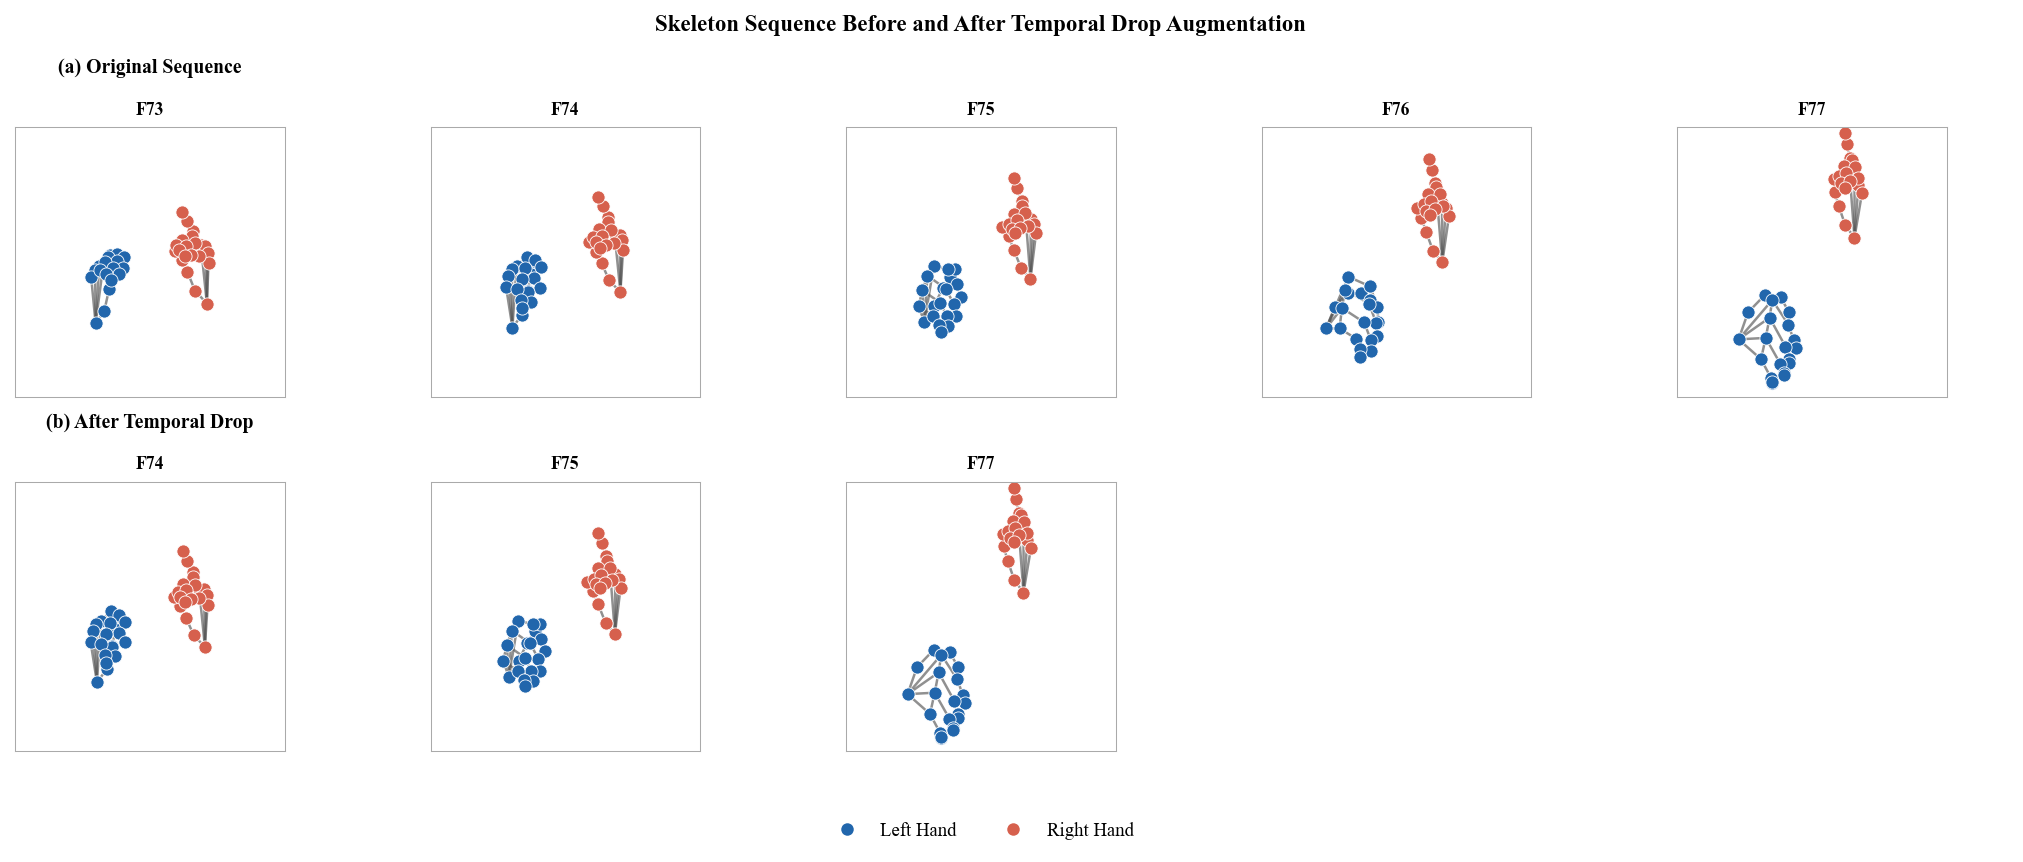

In [7]:
# Figure 2 — Temporal Drop: Skeleton Sequence Before vs. After

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Config ────────────────────────────────────────────────────────────────────
speaker_id   = "P01"
sequence_id  = "S023"
start_frame  = 73
num_frames   = 5
drop_ratio   = 0.4
margin_ratio = 0.08
rng = np.random.default_rng(42)

# ── Index & connections ───────────────────────────────────────────────────────
IDX_LH   = np.arange(0, 21)
IDX_RH   = np.arange(21, 42)
IDX_HAND = np.arange(0, 42)
hand_edges = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17)
]
connections = [(u,v) for u,v in hand_edges] + [(u+21,v+21) for u,v in hand_edges]

# ── Load data ─────────────────────────────────────────────────────────────────
match  = [k for k in data.keys() if k.startswith(f"{speaker_id}_{sequence_id}")]
vid    = sorted(match)[0]
kp_vid = data[vid]['keypoints']

frames_ori = []
for i in range(num_frames):
    fidx = start_frame + i
    if fidx < kp_vid.shape[0]:
        frames_ori.append((fidx, kp_vid[fidx].copy()))

# ── Temporal drop ─────────────────────────────────────────────────────────────
n       = len(frames_ori)
n_drop  = int(np.floor(drop_ratio * n))
drop_ids = set(rng.choice(n, size=n_drop, replace=False))
frames_drop = [frames_ori[i] for i in range(n) if i not in drop_ids]

# ── Alignment ─────────────────────────────────────────────────────────────────
def align(frame):
    valid = (frame[:,0] != 0) | (frame[:,1] != 0)
    idx   = IDX_HAND[valid[IDX_HAND]]
    if len(idx) == 0:
        return frame
    cx, cy = frame[idx,0].mean(), frame[idx,1].mean()
    frame[:,0] = -(frame[:,0] - cx)
    frame[:,1] -= cy
    return frame

aligned_ori  = [(f, align(fr.copy())) for f, fr in frames_ori]
aligned_drop = [(f, align(fr.copy())) for f, fr in frames_drop]

# ── Global scale ──────────────────────────────────────────────────────────────
all_x, all_y = [], []
for seq in [aligned_ori, aligned_drop]:
    for _, frame in seq:
        valid = (frame[:,0] != 0) | (frame[:,1] != 0)
        idx   = IDX_HAND[valid[IDX_HAND]]
        if len(idx):
            all_x.extend(frame[idx,0]);  all_y.extend(-frame[idx,1])
side = max(max(all_x)-min(all_x), max(all_y)-min(all_y)) * (1 + margin_ratio)

# ── Plot function ─────────────────────────────────────────────────────────────
def plot_seq(axs, seq, row_label):
    for ax, (fidx, frame) in zip(axs, seq):
        valid = (frame[:,0] != 0) | (frame[:,1] != 0)
        for u, v in connections:
            if valid[u] and valid[v]:
                ax.plot([frame[u,0], frame[v,0]], [-frame[u,1], -frame[v,1]],
                        color=C_EDGE, linewidth=1.2, alpha=0.65, zorder=1)
        def plot_region(indices, color):
            idx = indices[valid[indices]]
            ax.scatter(frame[idx,0], -frame[idx,1],
                       s=40, color=color, edgecolors='white',
                       linewidths=0.4, zorder=2)
        plot_region(IDX_LH, C_LH)
        plot_region(IDX_RH, C_RH)
        ax.set_xlim(-side/2, side/2);  ax.set_ylim(-side/2, side/2)
        ax.set_title(f"F{fidx}", fontsize=8.5)
        ax.set_aspect('equal');  ax.set_xticks([]);  ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_linewidth(0.5); spine.set_color('#aaaaaa')
    axs[0].text(0.5, 1.20, row_label, transform=axs[0].transAxes,
                ha='center', fontsize=9.5, fontweight='bold')

# ── Figure ────────────────────────────────────────────────────────────────────
n_cols = max(len(aligned_ori), len(aligned_drop))
fig, axes = plt.subplots(2, n_cols, figsize=(2.8*n_cols, 5.5), dpi=150)
if n_cols == 1:
    axes = axes.reshape(2,1)

plot_seq(axes[0], aligned_ori,  "(a) Original Sequence")
plot_seq(axes[1], aligned_drop, "(b) After Temporal Drop")

for r in range(2):
    for c in range(n_cols):
        if (r == 0 and c >= len(aligned_ori)) or (r == 1 and c >= len(aligned_drop)):
            axes[r,c].axis('off')

legend_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_LH,
           markeredgecolor='white', markersize=7, label='Left Hand'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_RH,
           markeredgecolor='white', markersize=7, label='Right Hand'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.04), frameon=False, fontsize=9)

plt.suptitle("Skeleton Sequence Before and After Temporal Drop Augmentation",
             fontsize=11, fontweight='bold')
plt.subplots_adjust(bottom=0.18, hspace=0.40, wspace=0.08)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()


## Figure 3 — Sequence Length Distribution After Temporal Drop

To understand the impact of temporal drop on data structure, we analyze frame counts before and after augmentation. Temporal drop randomly removes a subset of frames, resulting in shorter sequences.

This analysis aims to:
1. Quantify the frame reduction per sequence.
2. Observe the sequence length distribution after augmentation.
3. Verify that the frame reduction preserves temporal variation without eliminating primary motion patterns.


C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_24180\3184312135.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(


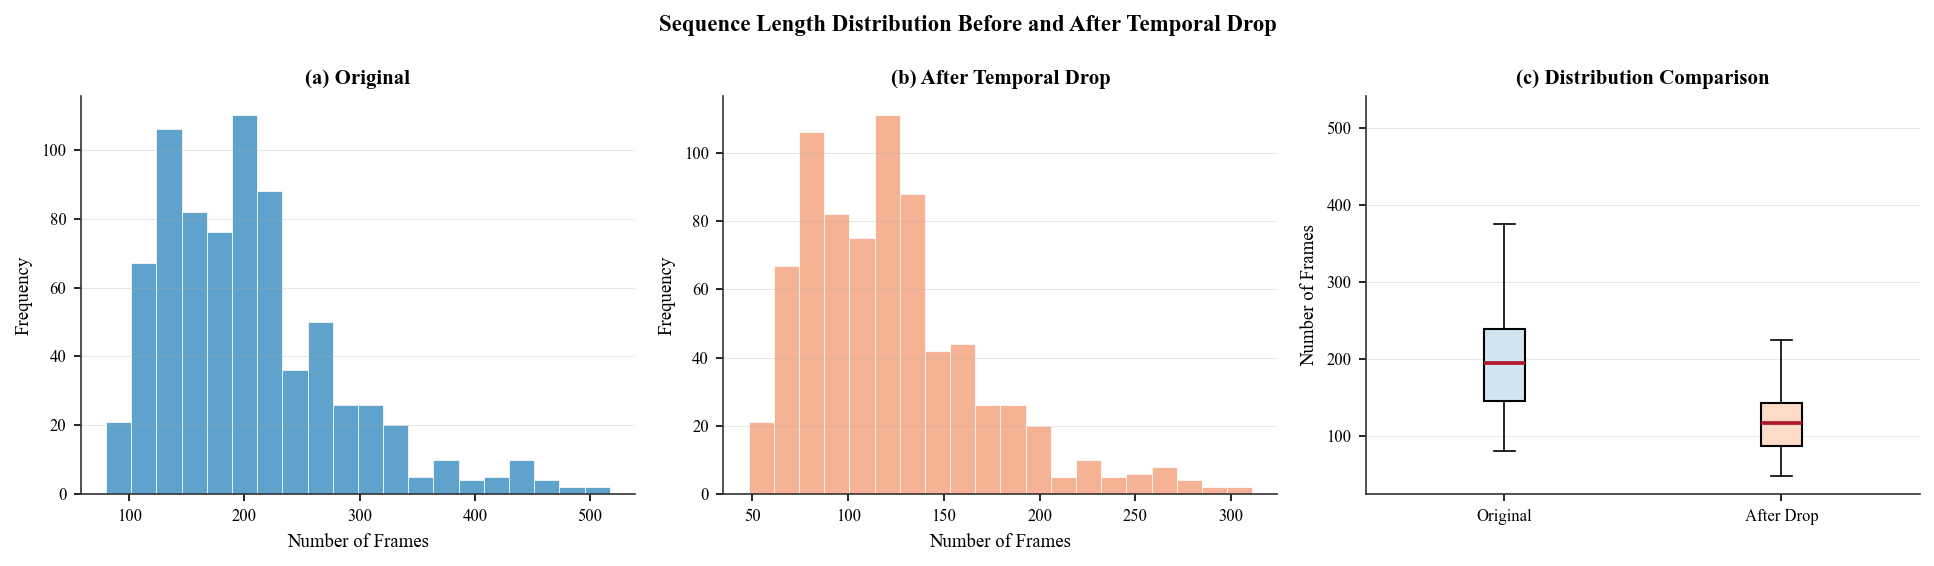

Mean (original) : 204.38
Mean (dropped)  : 122.67
Mean reduction  : 81.71


In [8]:
# Figure 3 — Sequence Length Distribution: Before vs. After Temporal Drop

import numpy as np
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
drop_ratio = 0.4
rng = np.random.default_rng(42)

original_lengths, dropped_lengths = [], []
for vid in data.keys():
    kp = data[vid]['keypoints']
    T  = kp.shape[0]
    if T < 5:
        continue
    original_lengths.append(T)
    dropped_lengths.append(T - int(np.floor(drop_ratio * T)))

original_lengths = np.array(original_lengths)
dropped_lengths  = np.array(dropped_lengths)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), dpi=150)

# Histogram – Original
axes[0].hist(original_lengths, bins=20, color=C_HIST1, alpha=0.85, edgecolor='white', linewidth=0.4)
axes[0].set_title("(a) Original")
axes[0].set_xlabel("Number of Frames");  axes[0].set_ylabel("Frequency")
axes[0].grid(axis='y', alpha=0.3, linewidth=0.5)

# Histogram – After Drop
axes[1].hist(dropped_lengths, bins=20, color=C_HIST2, alpha=0.85, edgecolor='white', linewidth=0.4)
axes[1].set_title("(b) After Temporal Drop")
axes[1].set_xlabel("Number of Frames");  axes[1].set_ylabel("Frequency")
axes[1].grid(axis='y', alpha=0.3, linewidth=0.5)

# Boxplot comparison
bp = axes[2].boxplot(
    [original_lengths, dropped_lengths],
    labels=["Original", "After Drop"],
    patch_artist=True,
    medianprops=dict(color=C_MED, linewidth=1.8),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
    flierprops=dict(marker='o', markersize=3, alpha=0.4, markeredgecolor='none'),
)
bp['boxes'][0].set_facecolor(C_BOX1)
bp['boxes'][1].set_facecolor(C_BOX2)
axes[2].set_title("(c) Distribution Comparison")
axes[2].set_ylabel("Number of Frames")
axes[2].grid(axis='y', alpha=0.3, linewidth=0.5)

for ax in axes:
    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)

plt.suptitle("Sequence Length Distribution Before and After Temporal Drop",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean (original) : {original_lengths.mean():.2f}")
print(f"Mean (dropped)  : {dropped_lengths.mean():.2f}")
print(f"Mean reduction  : {(original_lengths - dropped_lengths).mean():.2f}")


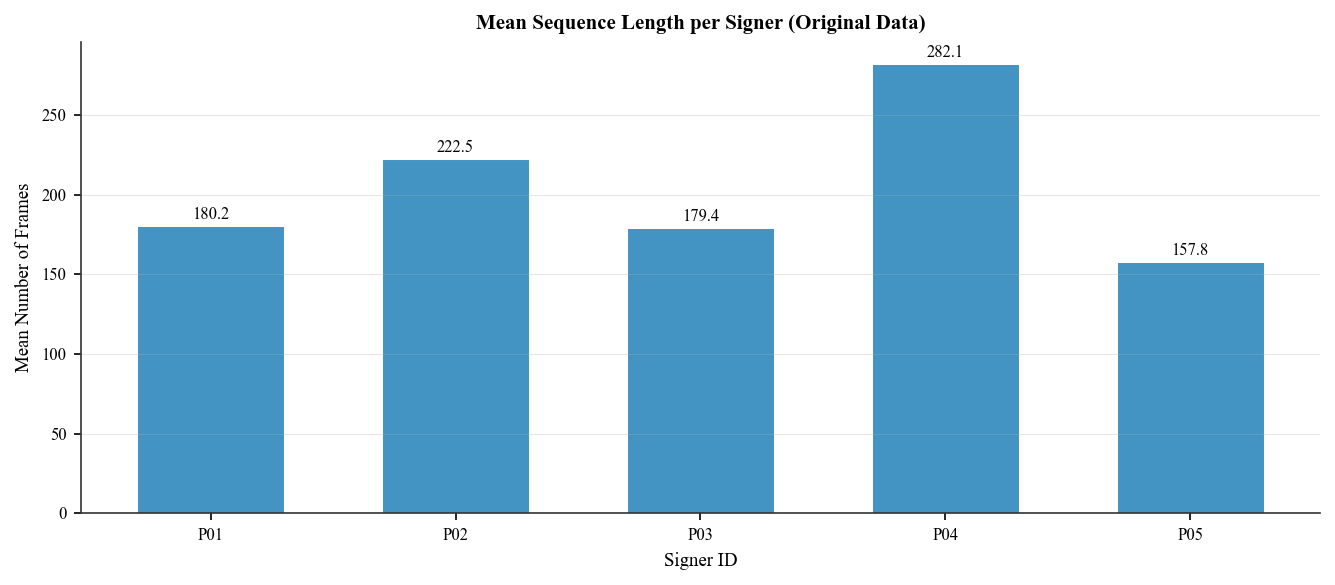

=== MEAN SEQUENCE LENGTH PER SIGNER ===
  P01: 180.18 frames
  P02: 222.47 frames
  P03: 179.35 frames
  P04: 282.11 frames
  P05: 157.77 frames


In [9]:
# Figure 4 — Mean Sequence Length per Signer (Original Data)

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ── Aggregate ─────────────────────────────────────────────────────────────────
speaker_lengths = defaultdict(list)
for vid in data.keys():
    kp = data[vid]['keypoints']
    T  = kp.shape[0]
    if T < 5:
        continue
    speaker = vid.split("_")[0]
    speaker_lengths[speaker].append(T)

speakers      = sorted(speaker_lengths.keys())
mean_original = [np.mean(speaker_lengths[s]) for s in speakers]

# ── Figure ────────────────────────────────────────────────────────────────────
x = np.arange(len(speakers))
fig, ax = plt.subplots(figsize=(9, 4), dpi=150)

bars = ax.bar(x, mean_original, color=C_BAR, edgecolor='white',
              linewidth=0.5, width=0.6)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 2,
            f"{h:.1f}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x);  ax.set_xticklabels(speakers)
ax.set_xlabel("Signer ID")
ax.set_ylabel("Mean Number of Frames")
ax.set_title("Mean Sequence Length per Signer (Original Data)", fontweight='bold')
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print("=== MEAN SEQUENCE LENGTH PER SIGNER ===")
for s, m in zip(speakers, mean_original):
    print(f"  {s}: {m:.2f} frames")
